In [75]:
import cv2
import numpy as np
from show_img import show_img

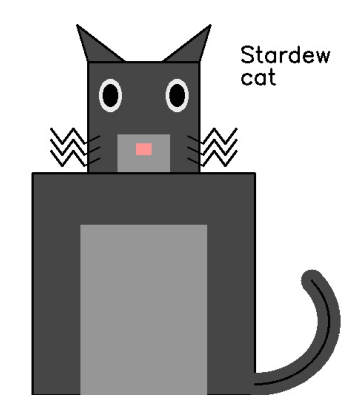

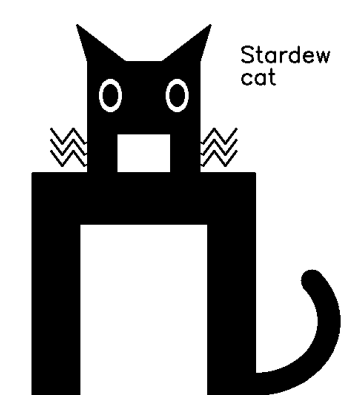

In [76]:
img = cv2.imread("my_cat.jpg")
show_img(img, size=5)
img_grayscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, img_thres = cv2.threshold(img_grayscale, 127, 255, cv2.THRESH_BINARY)
show_img(img_thres, size=5)

## Выделение контуров фигур

In [77]:
def show_perim_and_square(cnt):
   perim = cv2.arcLength(cnt, True)
   sqr = cv2.moments(cnt)['m00'] # получаем площадь из момента 00
   print(f"perimeter is {perim:.2f}, "
         f"square is {sqr:.2f}")

perimeter is 798.00, square is 38930.00
total rect count: 3


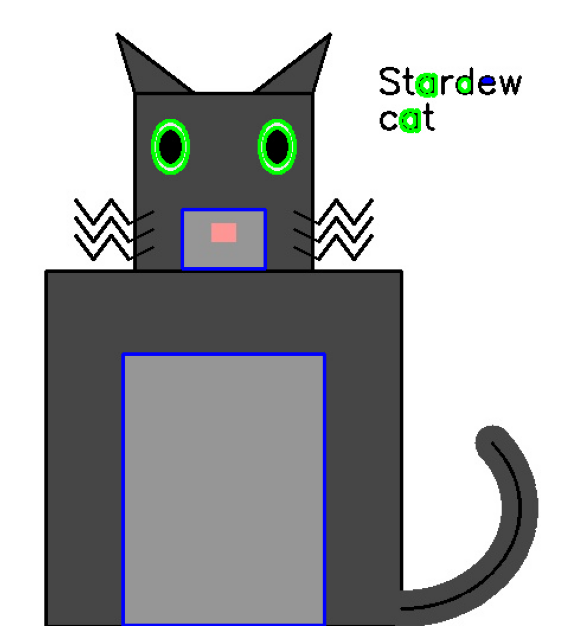

In [78]:
blue, green, red = (255, 0, 0), (0, 255, 0), (0, 0, 255)
contours, _ = cv2.findContours(img_thres, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

rect_num = 1 # номер прямоугольника для вычислений
rect_cnt = 0
img_con = img.copy()

for contour in contours:
    perim = cv2.arcLength(contour, True)

    if perim == 0:
        continue

    epsilon = 0.01 * perim
    sqr = cv2.contourArea(contour)
    approx = cv2.approxPolyDP(contour, epsilon, True)
    vertices = len(approx)

    is_circle = 4 * np.pi * (sqr / (perim*perim)) > 0.8

    if vertices == 4 and not is_circle:
        cv2.drawContours(img_con, [contour], 0, blue, 2)
        rect_cnt += 1
        if rect_num == rect_cnt: show_perim_and_square(contour)
    elif vertices > 5 and is_circle > 0.8:
        cv2.drawContours(img_con, [contour], 0, green, 2)
print(f"total rect count: {rect_cnt}")

show_img(img_con, size = 8)


## Выпуклый контур и дефекты контура

In [79]:
purple = (255, 0, 255)
yellow = (0, 255, 255)
lightblue = (255, 255, 0)
orange = (0, 165, 255)

def draw_shapes(img, cnt):
    # минимальный прямоугольник
    rect = cv2.minAreaRect(cnt) 
    box = np.intp(cv2.boxPoints(rect)) 
    cv2.drawContours(img, [box], 0, purple, 2)

    # круг
    (x_c, y_c), radius = cv2.minEnclosingCircle(cnt)
    center = (int(x_c), int(y_c))
    cv2.circle(img, center, int(radius), yellow, 2)

    # эллипс
    ellipse = cv2.fitEllipse(cnt) 
    cv2.ellipse(img, ellipse, lightblue, 2)

    # ось фигуры
    _, cols = img.shape[:2]
    vx, vy, xp, yp = cv2.fitLine(cnt, cv2.DIST_L2, 0, 0.01, 0.01).flatten()

    lefty = int((-xp*vy/vx) + yp)
    righty = int(((cols-xp)*vy/vx)+yp)
    cv2.line(img, (cols-1, righty), (0,lefty), orange, 4)

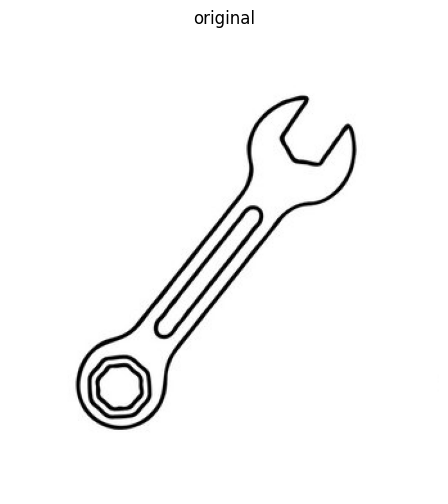

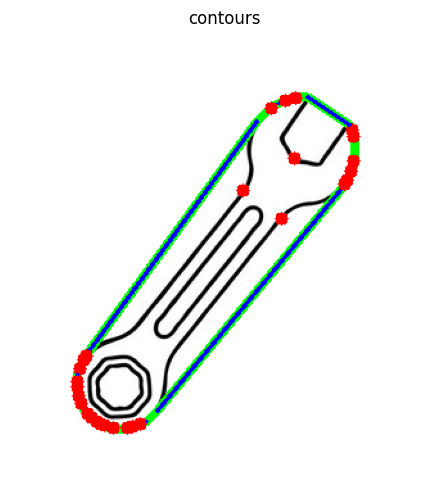

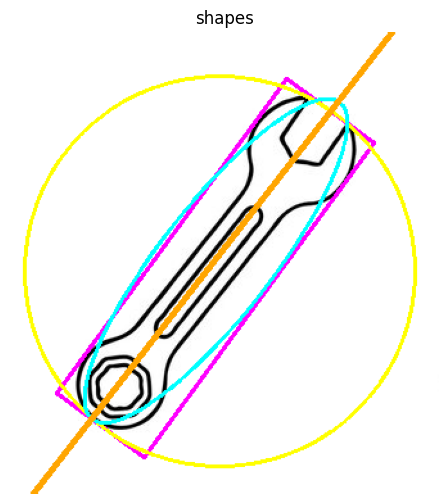

In [80]:
img2_orig = cv2.imread('spanner.png')
img2 = img2_orig.copy()
img2_shapes = img2_orig.copy()
img2_grayscale = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
_, img2_thres = cv2.threshold(img2_grayscale, 127, 255, cv2.THRESH_BINARY_INV)

contours2, _ = cv2.findContours(img2_thres, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours2:
    contour2 = max(contours2, key=cv2.contourArea)
    
    hull = cv2.convexHull(contour2)
    cv2.drawContours(img2, [hull], -1, green, 6) # контур выпуклой формы

    defects = cv2.convexityDefects(contour2, cv2.convexHull(contour2, returnPoints=False))
    if defects is not None:
        for i in range(defects.shape[0]):
            s, e, f, d = defects[i, 0]
            start = tuple(contour2[s][0])
            end = tuple(contour2[e][0])
            far = tuple(contour2[f][0])
            
            cv2.line(img2, start, end, blue, 2) # контур с дефектами
            cv2.circle(img2, far, 5, red, -1) # наиболее удаленные точки от контура

    draw_shapes(img2_shapes, contour2)

show_img(img2_orig, "original", size=6)
show_img(img2, "contours", size=6)
show_img(img2_shapes, "shapes", size=6)

## Наибольший контур вагона

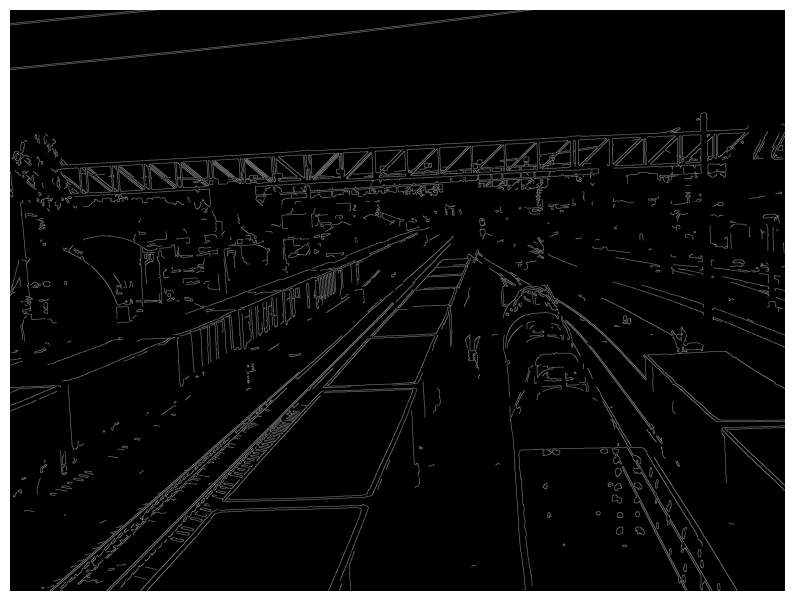

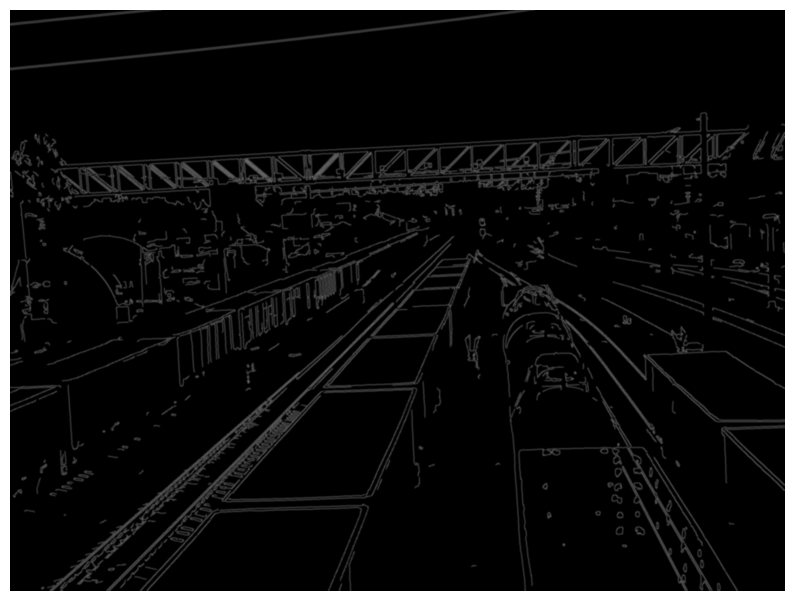

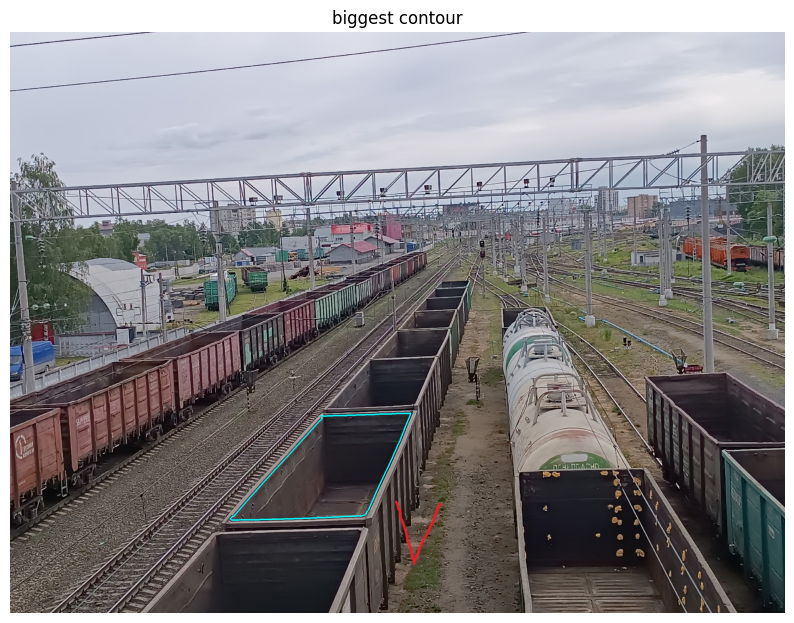

In [81]:
img3 = cv2.imread('railway_carriage.jpg')
img3_grayscale = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

img3_blur = cv2.GaussianBlur(img3_grayscale, (11, 11), 0) # убираем лишние шумы

img3_edges = cv2.Canny(img3_blur, 100, 200) # получаем границы объектов
show_img(img3_edges)

img3_edges = cv2.GaussianBlur(img3_edges, (11, 11), 0) # замыливаем получившиеся границы
show_img(img3_edges)

# получаем контуры с иерархией
contours3, hierarchy = cv2.findContours(img3_edges, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

max_sqr = 0 # максимальная площадь
best_contour = None # лучший найденный контур

if hierarchy is not None:
    for i, countour in enumerate(contours3):
        # ищем только контуры, находящиеся внутри других контуров
        if hierarchy[0][i][3] == -1: continue

        # получаем площадь
        sqr = cv2.contourArea(countour)
        
        if sqr > max_sqr:
            max_sqr = sqr
            best_contour = countour

if best_contour is not None:
    cv2.drawContours(img3, [best_contour], 0, lightblue, 3)

show_img(img3, "biggest contour")